# Part C – Feature Representation Improvement

## Objective

In Part C, an improvement is made to the image feature representation used in Part A.

The original image representation uses Canny edge detection with thresholds of 50 and 150.

In the improved representation, the Canny thresholds are changed to 30 and 100.

The original and improved representations are compared using accuracy, precision, recall, F1-score, confusion matrix, training time, prediction time, and number of features.

The same Logistic Regression classifier is used for both representations so that the effect of changing the feature representation can be compared fairly.

In [1]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 1. Dataset Paths

The dataset contains two classes:

- Cracks
- NonCracks

Crack images are assigned label 1 and non-crack images are assigned label 0.

In [2]:
CRACK_DIR = "Images/Cracks"
NONCRACK_DIR = "Images/NonCracks"

IMAGE_SIZE = (224, 224)

print("Crack folder:", CRACK_DIR)
print("Non-crack folder:", NONCRACK_DIR)
print("Image size:", IMAGE_SIZE)

Crack folder: Images/Cracks
Non-crack folder: Images/NonCracks
Image size: (224, 224)


## 2. Image Feature Extraction

For each image, intensity-based features are extracted:

- Mean brightness
- Contrast
- Dark-pixel ratio
- Bright-pixel ratio
- Minimum intensity
- Maximum intensity
- Median intensity
- Edge count
- Edge density

The main improvement in Part C is changing the Canny thresholds.

### Original representation
- Lower threshold = 50
- Upper threshold = 150

### Improved representation
- Lower threshold = 30
- Upper threshold = 100

Lower thresholds allow weaker edges to be detected, which may capture additional crack-related structures but may also introduce extra edges caused by texture or noise.

In [3]:
def extract_image_features(
    image_path,
    image_size=(224, 224),
    dark_threshold=50,
    bright_threshold=200,
    canny_low=50,
    canny_high=150
):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.resize(image, image_size)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_float = gray.astype(np.float32)

    mean_brightness = np.mean(gray_float)
    contrast = np.std(gray_float)

    dark_ratio = np.mean(gray < dark_threshold)
    bright_ratio = np.mean(gray > bright_threshold)

    min_intensity = np.min(gray_float)
    max_intensity = np.max(gray_float)
    median_intensity = np.median(gray_float)

    edges = cv2.Canny(gray, canny_low, canny_high)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_ratio": dark_ratio,
        "bright_ratio": bright_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

## 3. Extract the Original Representation

The original representation uses Canny thresholds of 50 and 150. This acts as the baseline for comparison.

In [4]:
original_data = []

for filename in os.listdir(CRACK_DIR):
    image_path = os.path.join(CRACK_DIR, filename)

    features = extract_image_features(
        image_path,
        canny_low=50,
        canny_high=150
    )

    if features is not None:
        features["filename"] = filename
        features["label"] = 1
        features["class"] = "Crack"
        original_data.append(features)

for filename in os.listdir(NONCRACK_DIR):
    image_path = os.path.join(NONCRACK_DIR, filename)

    features = extract_image_features(
        image_path,
        canny_low=50,
        canny_high=150
    )

    if features is not None:
        features["filename"] = filename
        features["label"] = 0
        features["class"] = "NonCrack"
        original_data.append(features)

original_df = pd.DataFrame(original_data)

print("Original representation shape:", original_df.shape)
display(original_df.head())

Original representation shape: (400, 12)


,mean_brightness,contrast,dark_ratio,bright_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density,filename,label,class
0,122.224609,31.513481,0.003846,0.010922,23.0,247.0,121.0,18520,0.369101,IMG_20180513_164959951_HDR resized_448.jpg,1,Crack
1,131.948685,24.096115,0.002790,0.003787,8.0,251.0,133.0,18094,0.360611,IMG_20180513_165129852_HDR resized_448.jpg,1,Crack
2,121.297310,29.884272,0.013333,0.008171,2.0,241.0,121.0,17454,0.347856,IMG_20180513_165150613_HDR resized_448.jpg,1,Crack
3,130.245590,25.649017,0.001893,0.004006,20.0,253.0,131.0,18767,0.374023,IMG_20180513_165345878_HDR resized_448.jpg,1,Crack
4,131.208878,26.237600,0.002372,0.006258,11.0,254.0,132.0,18349,0.365693,IMG_20180513_165349788_HDR resized_448.jpg,1,Crack


## 4. Extract the Improved Representation

The improved representation changes the Canny thresholds from 50/150 to 30/100.

Lower thresholds allow weaker edges to be detected.

In [5]:
improved_data = []

for filename in os.listdir(CRACK_DIR):
    image_path = os.path.join(CRACK_DIR, filename)

    features = extract_image_features(
        image_path,
        canny_low=30,
        canny_high=100
    )

    if features is not None:
        features["filename"] = filename
        features["label"] = 1
        features["class"] = "Crack"
        improved_data.append(features)

for filename in os.listdir(NONCRACK_DIR):
    image_path = os.path.join(NONCRACK_DIR, filename)

    features = extract_image_features(
        image_path,
        canny_low=30,
        canny_high=100
    )

    if features is not None:
        features["filename"] = filename
        features["label"] = 0
        features["class"] = "NonCrack"
        improved_data.append(features)

improved_df = pd.DataFrame(improved_data)

print("Improved representation shape:", improved_df.shape)
display(improved_df.head())

Improved representation shape: (400, 12)


,mean_brightness,contrast,dark_ratio,bright_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density,filename,label,class
0,122.224609,31.513481,0.003846,0.010922,23.0,247.0,121.0,18770,0.374083,IMG_20180513_164959951_HDR resized_448.jpg,1,Crack
1,131.948685,24.096115,0.002790,0.003787,8.0,251.0,133.0,18951,0.377691,IMG_20180513_165129852_HDR resized_448.jpg,1,Crack
2,121.297310,29.884272,0.013333,0.008171,2.0,241.0,121.0,18544,0.369579,IMG_20180513_165150613_HDR resized_448.jpg,1,Crack
3,130.245590,25.649017,0.001893,0.004006,20.0,253.0,131.0,19169,0.382035,IMG_20180513_165345878_HDR resized_448.jpg,1,Crack
4,131.208878,26.237600,0.002372,0.006258,11.0,254.0,132.0,18750,0.373685,IMG_20180513_165349788_HDR resized_448.jpg,1,Crack


## 5. Compare Edge Features

The Canny threshold change should mainly affect the edge-related features. The average edge count and edge density are compared between the original and improved representations.

In [6]:
edge_comparison = pd.DataFrame({
    "Feature": [
        "Average Edge Count",
        "Average Edge Density"
    ],
    "Original (50,150)": [
        original_df["edge_count"].mean(),
        original_df["edge_density"].mean()
    ],
    "Improved (30,100)": [
        improved_df["edge_count"].mean(),
        improved_df["edge_density"].mean()
    ]
})

display(edge_comparison)

,Feature,"Original (50,150)","Improved (30,100)"
0,Average Edge Count,17675.49500,18729.657500
1,Average Edge Density,0.35227,0.373279


## 6. Visual Comparison of Canny Edges

A sample crack image is displayed using both Canny configurations to visually inspect the effect of changing the thresholds.

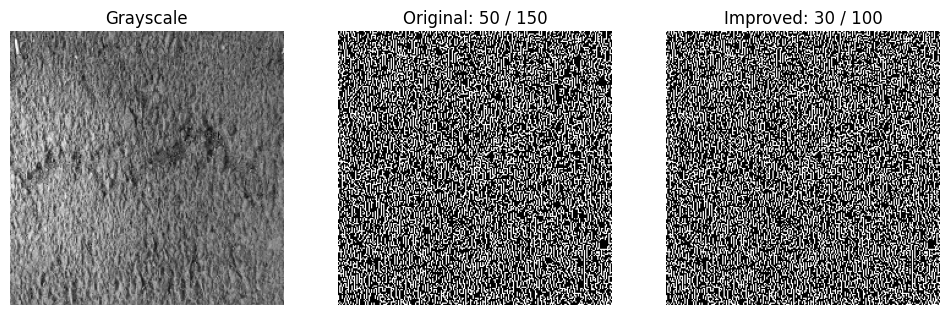

In [7]:
filename = os.listdir(CRACK_DIR)[0]
path = os.path.join(CRACK_DIR, filename)

image = cv2.imread(path)
image = cv2.resize(image, IMAGE_SIZE)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

original_edges = cv2.Canny(gray, 50, 150)
improved_edges = cv2.Canny(gray, 30, 100)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(original_edges, cmap="gray")
plt.title("Original: 50 / 150")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(improved_edges, cmap="gray")
plt.title("Improved: 30 / 100")
plt.axis("off")

plt.show()

## 7. Prepare Features and Target

Filename and class are metadata and are not used for training.

The numerical image features are used as input variables, while the label is the target variable.

In [8]:
feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_ratio",
    "bright_ratio",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "edge_count",
    "edge_density"
]

X_original = original_df[feature_columns]
y_original = original_df["label"]

X_improved = improved_df[feature_columns]
y_improved = improved_df["label"]

print("Original X shape:", X_original.shape)
print("Improved X shape:", X_improved.shape)
print("Target shape:", y_original.shape)

Original X shape: (400, 9)
Improved X shape: (400, 9)
Target shape: (400,)


## 8. Train-Test Split

The same train-test split settings are used for both representations.

Stratification maintains the proportion of crack and non-crack images in the training and testing sets.

The same random state makes the comparison consistent.

In [9]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y_original,
    test_size=0.20,
    random_state=42,
    stratify=y_original
)

X_train_improved, X_test_improved, y_train_improved, y_test_improved = train_test_split(
    X_improved,
    y_improved,
    test_size=0.20,
    random_state=42,
    stratify=y_improved
)

print("Original training data:", X_train_original.shape)
print("Original testing data:", X_test_original.shape)

print("\nImproved training data:", X_train_improved.shape)
print("Improved testing data:", X_test_improved.shape)

Original training data: (320, 9)
Original testing data: (80, 9)

Improved training data: (320, 9)
Improved testing data: (80, 9)


## 9. Logistic Regression Model

Logistic Regression is used to compare the original and improved representations.

StandardScaler is included because the extracted features have different numerical scales. For example, edge count can have a much larger numerical value than a ratio such as dark-pixel ratio.

A pipeline ensures that scaling is performed consistently.

In [10]:
original_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

improved_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Models created.")

Models created.


## 10. Evaluation Function

The same evaluation procedure is applied to both models.

The following measurements are recorded:

- Accuracy
- Precision
- Recall
- F1-score
- Training time
- Prediction time
- Confusion matrix

In [11]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_prediction = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_prediction

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time": train_time,
        "Prediction Time": prediction_time,
        "Confusion Matrix": cm
    }

## 11. Evaluate Original Representation

The baseline Logistic Regression model is trained using the original Canny representation.

In [12]:
original_result = evaluate_model(
    original_model,
    X_train_original,
    X_test_original,
    y_train_original,
    y_test_original
)

print("Original Representation")
print("=" * 40)

print("Accuracy:", original_result["Accuracy"])
print("Precision:", original_result["Precision"])
print("Recall:", original_result["Recall"])
print("F1 Score:", original_result["F1 Score"])

print("Training Time:", original_result["Training Time"])
print("Prediction Time:", original_result["Prediction Time"])

print("\nConfusion Matrix:")
print(original_result["Confusion Matrix"])

Original Representation
Accuracy: 0.9375
Precision: 0.926829268292683
Recall: 0.95
F1 Score: 0.9382716049382716
Training Time: 0.02313971519470215
Prediction Time: 0.0026123523712158203

Confusion Matrix:
[[37  3]
 [ 2 38]]


## 12. Evaluate Improved Representation

The Logistic Regression model is now trained using the representation created with the modified Canny thresholds.

In [13]:
improved_result = evaluate_model(
    improved_model,
    X_train_improved,
    X_test_improved,
    y_train_improved,
    y_test_improved
)

print("Improved Representation")
print("=" * 40)

print("Accuracy:", improved_result["Accuracy"])
print("Precision:", improved_result["Precision"])
print("Recall:", improved_result["Recall"])
print("F1 Score:", improved_result["F1 Score"])

print("Training Time:", improved_result["Training Time"])
print("Prediction Time:", improved_result["Prediction Time"])

print("\nConfusion Matrix:")
print(improved_result["Confusion Matrix"])

Improved Representation
Accuracy: 0.9375
Precision: 0.926829268292683
Recall: 0.95
F1 Score: 0.9382716049382716
Training Time: 0.0700833797454834
Prediction Time: 0.0026471614837646484

Confusion Matrix:
[[37  3]
 [ 2 38]]


## 13. Compare Original and Improved Representations

The results of both representations are placed in one table.

The comparison considers predictive performance and computational cost.

In [14]:
comparison = pd.DataFrame({
    "Metric": [
        "Number of Features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time",
        "Prediction Time"
    ],
    "Original": [
        X_train_original.shape[1],
        original_result["Accuracy"],
        original_result["Precision"],
        original_result["Recall"],
        original_result["F1 Score"],
        original_result["Training Time"],
        original_result["Prediction Time"]
    ],
    "Improved": [
        X_train_improved.shape[1],
        improved_result["Accuracy"],
        improved_result["Precision"],
        improved_result["Recall"],
        improved_result["F1 Score"],
        improved_result["Training Time"],
        improved_result["Prediction Time"]
    ]
})

display(comparison)

,Metric,Original,Improved
0,Number of Features,9.000000,9.000000
1,Accuracy,0.937500,0.937500
2,Precision,0.926829,0.926829
3,Recall,0.950000,0.950000
4,F1 Score,0.938272,0.938272
5,Training Time,0.023140,0.070083
6,Prediction Time,0.002612,0.002647


## 14. Classification Reports

Detailed classification reports are displayed for both representations.

In [15]:
original_predictions = original_model.predict(X_test_original)
improved_predictions = improved_model.predict(X_test_improved)

print("ORIGINAL REPRESENTATION")
print("=" * 50)

print(
    classification_report(
        y_test_original,
        original_predictions,
        zero_division=0
    )
)

print("\nIMPROVED REPRESENTATION")
print("=" * 50)

print(
    classification_report(
        y_test_improved,
        improved_predictions,
        zero_division=0
    )
)

ORIGINAL REPRESENTATION
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        40
           1       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80


IMPROVED REPRESENTATION
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        40
           1       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80



## 15. Percentage Change in Performance

The percentage change in the main evaluation metrics is calculated to make the effect of the representation change easier to interpret.

In [16]:
def percentage_change(original, improved):
    if original == 0:
        return np.nan
    return ((improved - original) / original) * 100

print(
    "Accuracy change:",
    round(percentage_change(
        original_result["Accuracy"],
        improved_result["Accuracy"]
    ), 2),
    "%"
)

print(
    "Precision change:",
    round(percentage_change(
        original_result["Precision"],
        improved_result["Precision"]
    ), 2),
    "%"
)

print(
    "Recall change:",
    round(percentage_change(
        original_result["Recall"],
        improved_result["Recall"]
    ), 2),
    "%"
)

print(
    "F1-score change:",
    round(percentage_change(
        original_result["F1 Score"],
        improved_result["F1 Score"]
    ), 2),
    "%"
)

Accuracy change: 0.0 %
Precision change: 0.0 %
Recall change: 0.0 %
F1-score change: 0.0 %


## 16. Conclusion

The original representation used Canny thresholds of 50 and 150, while the improved representation used thresholds of 30 and 100.

The lower thresholds allow weaker edges to be detected, changing the edge-related features of the image representation.

Both representations were evaluated using the same Logistic Regression classifier and the same train-test split.

The final comparison considers predictive performance as well as computational cost.

The improved representation should only be considered beneficial if the experimental results support an improvement in the required performance measures. If performance decreases, the result still demonstrates the trade-off caused by changing the feature representation.